IMPORTING IBRARIES

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

IMPORTING DATASET

In [43]:
dataset = pd.read_csv('Credit_Card_Applications.csv')

x = dataset.iloc[:,:-1].values
y = dataset.iloc[:,-1].values


FEATURE SCALING

In [44]:
from sklearn.preprocessing import MinMaxScaler
sc = MinMaxScaler(feature_range=(0,1))
x = sc.fit_transform(x)

TRAINING THE SOM

In [45]:
from minisom import MiniSom

som = MiniSom(x = 10, y = 10, input_len = 15, sigma = 0.1, learning_rate = 0.5)
som.random_weights_init(x)
som.train_random(data = x, num_iteration = 100)

VISUALIZING THE RESULTS

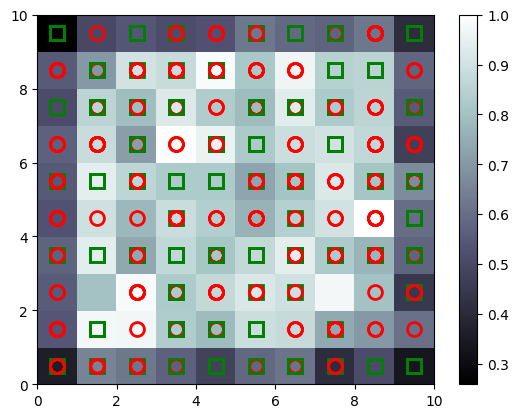

In [46]:
from pylab import bone
from pylab import pcolor
from pylab import colorbar
from pylab import plot
from pylab import show

bone()

pcolor(som.distance_map().T)
colorbar()
markers = ['o', 's']
colors = ['r', 'g']

for i, x in enumerate(x):
  w = som.winner(x)
  plot(w[0] + 0.5,
       w[1] + 0.5,
       markers[y[i]],
       markeredgecolor = colors[y[i]],
       markerfacecolor = 'None',
       markersize = 10,
       markeredgewidth = 2)

show()